In [17]:
import copy
import math
from typing import List, Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, Dataset
import matplotlib.pyplot as plt
# import flwr_datasets
from datasets import concatenate_datasets


In [18]:
num_helpers = 3
num_clients = 4

In [19]:
#assuming the number of samples fit in a 4 byte integer
def payload(item):
    if item is None:
        return 0
    ret = 0
    state = item[0]
    for k in state:
        if is_0d_tensor_pytorch(state[k]):
            ret += 4
        else:
            ret += state[k].nbytes
    return ret

def is_0d_tensor_pytorch(value):
    return torch.is_tensor(value) and value.dim() == 0
# def payload(item):
#     if item is None:
#         return 0
#     ret = 0
#     state = item[0]
#     print(type(state))
#     print(state.nbytes)
#     return state.nbytes
#     for k in state:
#         if is_0d_tensor_pytorch(state[k]):
#             ret += 4
#         else :
#             ret += state[k].nbytes
#     return ret

In [20]:
class HFWrapper(Dataset):
    def __init__(
        self, hf_dataset, image_key="image", label_key="character",
    ):
        self.hf = hf_dataset
        self.image_key = image_key
        self.label_key = label_key
        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.hf)

    def __getitem__(self, idx):
        item = self.hf[idx]
        img = item[self.image_key]
        label = item[self.label_key]
        img = self.transform(img)
        return img, label



def make_loader(hf_dataset, batch_size=32, shuffle=False):
    wrapped = HFWrapper(hf_dataset)
    return DataLoader(
        wrapped,
        batch_size=batch_size,
        shuffle=shuffle,
    )

In [21]:
class FEMNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 7, padding=3)
        self.act = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc = nn.Linear(64 * 7 * 7, 62)   # 62 classes in FEMNIST

    def forward(self, x):
        x = x.reshape(-1, 1, 28, 28)
        x = self.pool(self.act(self.conv1(x)))
        x = self.pool(self.act(self.conv2(x)))
        x = x.flatten(1)
        return self.fc(x)

In [22]:
class Helper(dict):
    def __init__(self,idx):
        self.hid = idx


helper_nodes = []
for i in range(num_helpers):
    helper_nodes.append(Helper(i))

In [23]:
import random

# failure_dict: {int,[int]}
num_clients, num_helpers = 4,3 

failure_dict = dict()

for i in range(num_helpers):
    failure_dict[i] = []

def random_failure_matrix(num_helpers: int, num_clients: int) -> [[int]]:
    # we are assuming that one helper fails for simplicity
    matrix = []
    for i in range(num_clients):
        row = [0] * num_helpers
        ind = random.choice(range(num_helpers))
        row[ind] = 1
        matrix.append(row)
        failure_dict[ind].append(i)
    return matrix

num_clients, num_helpers = 4,3
failure_matrix = random_failure_matrix(num_helpers, num_clients)

print("Failure Matrix:")
for row in failure_matrix:
    print(row)

for key,value in failure_dict.items():
    print(key,value)


Failure Matrix:
[0, 1, 0]
[0, 0, 1]
[0, 0, 1]
[0, 0, 1]
0 []
1 [0]
2 [1, 2, 3]


In [24]:
import random
import torch

def client_to_helper(cid,item):
    state_dict = item[0]
    num_samples = item[1]
    first_piece = {}
    second_piece = {}
    parity_piece = {}
    for name, param in state_dict.items():
        if param.dim() > 0 and param.size(0) % 2 == 0 and param.size(0) > 1:
            half = param.size(0) // 2

            first_half = param[:half].clone()
            second_half = param[half:].clone()
            parity = first_half + second_half

            first_piece[name] = first_half
            second_piece[name] = second_half
            parity_piece[name] = parity
    codes = [first_piece,second_piece,parity_piece]
    eve = random.randint(0,9)
    helper_nodes[0][cid]=(codes[0],num_samples)
    helper_nodes[1][cid]=(codes[1],num_samples)
    helper_nodes[2][cid]=(codes[2],num_samples)
    #for now think there are no failures
    # if eve<3:
    #     helper_nodes[eve][cid]=None
    # for i in range(len(failure_matrix[cid])):
    #     curr = failure_matrix[cid]
    #     if curr[i] == 1:
    #         helper_nodes[i][cid]=None
    # helper_nodes[cid][] = None
    # print("payloads of pieces: ",payload(first_half),payload(second_half),payload(parity))
    return first_piece, second_piece, parity_piece

def reconstruct_state(code):
    num_samp = 0
    fp = dict()
    sp = dict()
    tp = dict()
    if code[0] is not None:
        num_samp = code[0][1]
    else:
        num_samp = code[1][1]
    if code[0] is None:
        sp:dict
        sp,tp = code[1][0],code[2][0]
        fp = dict()
        for key in sp.keys():
            fp[key]=tp[key]-sp[key]
    elif code[1] is None:
        fp,tp = code[0][0],code[2][0]
        sp = dict()
        for key in fp.keys():
            sp[key]=tp[key]-fp[key]
    else:
        fp,sp = code[0][0],code[1][0]
    model_state = dict()
    for key in fp.keys():
        model_state[key]=torch.cat((fp[key],sp[key]),dim=0)
    return (model_state,num_samp)
        
    
    
def helper_to_master():
    updates = []
    # updates = num_clients*[None]
    # for h in helper_nodes:
    #     # print(type(h))
    #     for entry in h.items():
    #         # print(type(entry[1]))
    #         if entry[1] is not None :
    #             updates[entry[0]]=entry[1]
    client_wts = num_clients*[None]
    for i in range(num_clients):
        client_wts[i]=[helper_nodes[0][i],helper_nodes[1][i],helper_nodes[2][i]]
    for code in client_wts:
        updates.append(reconstruct_state(code))
    return updates


def helper_aggregate(updates):
    if len(updates) == 0:
        return {},0
    total_samples = sum(num for _, num in updates)
    if total_samples is None:
        total_samples = 0
    new_state = {}

    for key in updates[0][0].keys():
        weighted = sum(
            (client_state[key] * (num / total_samples))
            for client_state, num in updates
        )
        new_state[key] = weighted
    return new_state,total_samples

def agg_helper_to_master():
    updates = []
    #this is aggregate
    # total_samples = sum(num for _, num in updates)
    # new_state = {}

    # for key in updates[0][0].keys():
    #     weighted = sum(
    #         (client_state[key] * (num / total_samples))
    #         for client_state, num in updates
    #     )
    #     new_state[key] = weighted
    
    for key,val in failure_dict.items():
        # if key == 0:
        if len(val) == 0:
            continue
        la = [[],[],[]]
        tot_samples = 0
        for node in val:
            # la[0].append(reconstruct_state([helper_nodes[0][node],helper_nodes[1][node],helper_nodes[2][node]]))
            la[0].append(helper_nodes[0][node])
            la[1].append(helper_nodes[1][node])
            la[2].append(helper_nodes[2][node])
        if key == 0:
            la[0] = None
            la[1] = helper_aggregate(la[1])
            la[2] = helper_aggregate(la[2])
        elif key == 1:
            la[0] = helper_aggregate(la[0])
            la[1] = None
            la[2] = helper_aggregate(la[2])
        else:
            la[0] = helper_aggregate(la[0])
            la[1] = helper_aggregate(la[1])
            la[2] = None
        
        # la = list(map(helper_aggregate,la))
        # updates.append(la[0],la[1],la[2])
        payloads = map(payload,la)
        updates.append(reconstruct_state(la))
        print("Actual Payloads are:",*payloads)
        # for _,numsam in la:
        #     tot_samples += numsam
        # ret = helper_aggregate(la)
        # updates.append(ret)
        # if len(ret)!=0:
        #     updates.append(ret)
        # elif key ==1:
        # else key ==2:        
    return updates
    

In [25]:
class Client:
    def __init__(self,cid, dataset, device="cpu"):
        self.cid = cid
        self.dataset = dataset
        self.device = device

    def train_local(self, global_model, epochs=1, batch_size=32, lr=0.01):
        model = copy.deepcopy(global_model).to(self.device)
        loader = make_loader(self.dataset, batch_size=batch_size, shuffle=True)
        optimizer = optim.SGD(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for _ in range(epochs):
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                loss.backward()
                optimizer.step()
        for name, param in model.state_dict().items():
            print(f"{name}: {param.shape}")
        client_to_helper(self.cid,(model.state_dict(), len(self.dataset)))
        return model.state_dict(), len(self.dataset)


In [26]:
class Master:
    def __init__(self, global_model, clients, device="cpu"):
        self.global_model = global_model
        self.clients = clients
        self.device = device

    def aggregate(self, updates):
        total_samples = sum(num for _, num in updates)
        new_state = {}

        for key in updates[0][0].keys():
            weighted = sum(
                (client_state[key] * (num / total_samples))
                for client_state, num in updates
            )
            new_state[key] = weighted

        self.global_model.load_state_dict(new_state)

    def run_round(self, epochs=1, batch_size=32, lr=0.01):
        # updates = num_clients*[None]
        for client in self.clients:
            client_state, num_samples = client.train_local(
                self.global_model, epochs=epochs, batch_size=batch_size, lr=lr
            )
        # updates = helper_to_master()
        updates = agg_helper_to_master()
        self.aggregate(updates)

    def evaluate(self, test_dataset, batch_size=64):
        loader = make_loader(test_dataset, batch_size=batch_size)
        model = self.global_model.to(self.device)
        model.eval()

        total, correct, total_loss = 0, 0, 0
        criterion = nn.CrossEntropyLoss()

        with torch.no_grad():
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                outputs = model(X)
                total_loss += criterion(outputs, y).item() * y.size(0)
                correct += (outputs.argmax(1) == y).sum().item()
                total += y.size(0)

        return total_loss / total, correct / total

In [27]:
def weighted_average(updates):
    """Weighted average of model weights based on dataset sizes."""
    total_examples = sum(num for _, num in updates)
    new_state = {}

    for key in updates[0][0].keys():
        new_state[key] = sum((state[key] * num for state, num in updates), 
                             torch.zeros_like(updates[0][0][key]))
        new_state[key] /= total_examples

    return new_state, total_examples

In [28]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import IidPartitioner, GroupedNaturalIdPartitioner
from datasets import ClassLabel
from torch.utils.data import DataLoader

num_clients = 4
num_helper = 3


# partitioner = IidPartitioner(num_partitions=num_clients)
# partitioner = Partitioner
# partitioner = GroupedNaturalIdPartitioner(num_partitions=num_clients, id_column="writer_id")
partitioner = GroupedNaturalIdPartitioner(partition_by='writer_id',group_size=10)
dataset = FederatedDataset(
    dataset="flwrlabs/femnist", partitioners={"train": partitioner}
)

partition  = dataset.load_partition(0,'train')
partition.set_format(type='torch',columns=['character'])
print(partition.features)

client_subsets = []
test_datasubsets = []



for i in range(num_clients):
    curr_part = dataset.load_partition(partition_id=i, split="train")
    split_data = curr_part.train_test_split(test_size=0.2, seed=42)    
    assert len(split_data['test'])>0 and len(split_data['train'])>0
    client_subsets.append(split_data["train"])
    test_datasubsets.append(split_data["test"])
clients = [Client(cid=i, dataset=client_subsets[i]) for i in range(num_clients)]


train_data = concatenate_datasets(client_subsets)
train_loader = make_loader(train_data, batch_size=256, shuffle=True)
test_data = concatenate_datasets(test_datasubsets)
test_loader = make_loader(test_data,batch_size=256,shuffle=False)





{'image': Image(mode=None, decode=True, id=None), 'writer_id': Value(dtype='string', id=None), 'hsf_id': Value(dtype='int64', id=None), 'character': ClassLabel(names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'], id=None)}


In [29]:
cl_acc = []
def train_central(model, train_loader, test_loader, device='cpu', epochs=5):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
        
        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                pred = out.argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)
        acc = correct / total
        print(f"Epoch {epoch+1}: Test Accuracy: {acc*100:.2f}%")
        cl_acc.append(acc*100)



In [30]:

global_model = FEMNISTNet()
master = Master(global_model, clients, device="cpu")

fl_acc = []
fl_loss = []
ROUNDS = 2
for r in range(1, ROUNDS + 1):
    print(f"--- Round {r} ---")
    master.run_round(epochs=2, batch_size=32, lr=0.05)
    loss, acc = master.evaluate(test_data)
    print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc*100:.2f}%")
    fl_acc.append(acc*100)
    fl_loss.append(loss)

--- Round 1 ---
conv1.weight: torch.Size([32, 1, 7, 7])
conv1.bias: torch.Size([32])
conv2.weight: torch.Size([64, 32, 3, 3])
conv2.bias: torch.Size([64])
fc.weight: torch.Size([62, 3136])
fc.bias: torch.Size([62])
conv1.weight: torch.Size([32, 1, 7, 7])
conv1.bias: torch.Size([32])
conv2.weight: torch.Size([64, 32, 3, 3])
conv2.bias: torch.Size([64])
fc.weight: torch.Size([62, 3136])
fc.bias: torch.Size([62])
conv1.weight: torch.Size([32, 1, 7, 7])
conv1.bias: torch.Size([32])
conv2.weight: torch.Size([64, 32, 3, 3])
conv2.bias: torch.Size([64])
fc.weight: torch.Size([62, 3136])
fc.bias: torch.Size([62])
conv1.weight: torch.Size([32, 1, 7, 7])
conv1.bias: torch.Size([32])
conv2.weight: torch.Size([64, 32, 3, 3])
conv2.bias: torch.Size([64])
fc.weight: torch.Size([62, 3136])
fc.bias: torch.Size([62])
Actual Payloads are: 429180 0 429180
Actual Payloads are: 429180 429180 0
Test Loss: 3.5275, Test Accuracy: 11.27%
--- Round 2 ---
conv1.weight: torch.Size([32, 1, 7, 7])
conv1.bias: torch

In [31]:
print("dataset size is:",len(train_data))
central_model = FEMNISTNet()
train_central(central_model,train_loader,test_loader,device='cpu',epochs=4)

dataset size is: 11774
Epoch 1: Test Accuracy: 18.36%
Epoch 2: Test Accuracy: 46.67%
Epoch 3: Test Accuracy: 59.71%
Epoch 4: Test Accuracy: 65.72%


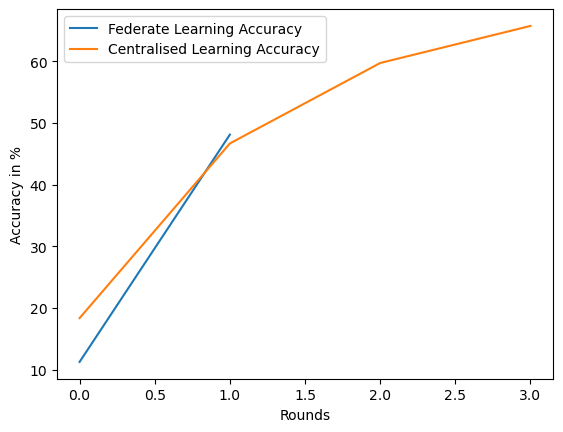

In [32]:
import matplotlib.pyplot as plt
plt.plot(fl_acc,label="Federate Learning Accuracy")
plt.plot(cl_acc,label="Centralised Learning Accuracy")
plt.legend()
plt.xlabel("Rounds")
plt.ylabel("Accuracy in %")
plt.show()
